In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load processed master dataset
df = pd.read_csv("../data/processed/ecommerce_master.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (99441, 39)

Columns:
['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days', 'customer_city', 'customer_state', 'product_value', 'freight_value', 'order_value', 'freight_ratio', 'item_count', 'unique_products', 'unique_sellers', 'product_categories', 'product_count', 'unique_product_count', 'seller_count', 'seller_ids', 'seller_states', 'payment_value', 'payment_records', 'payment_installments_max', 'primary_payment_type', 'review_score_avg', 'review_score_min', 'review_score_max', 'review_count', 'is_late', 'is_repeat_customer', 'purchase_year', 'purchase_month', 'purchase_year_month']

Data Types:
order_id                          object
customer_id                       object
customer_unique_id                object
order_status                      object
order_purchase_timestamp 

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,customer_city,customer_state,product_value,freight_value,order_value,freight_ratio,item_count,unique_products,unique_sellers,product_categories,product_count,unique_product_count,seller_count,seller_ids,seller_states,payment_value,payment_records,payment_installments_max,primary_payment_type,review_score_avg,review_score_min,review_score_max,review_count,is_late,is_repeat_customer,purchase_year,purchase_month,purchase_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,sao paulo,SP,29.99,8.72,38.71,0.290764,1.0,1.0,1.0,housewares,1.0,1.0,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,SP,38.71,3.0,1.0,credit_card,4.0,4.0,4.0,1.0,0,1,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,barreiras,BA,118.70,22.76,141.46,0.191744,1.0,1.0,1.0,perfumery,1.0,1.0,1.0,289cdb325fb7e7f891c38608bf9e0962,SP,141.46,1.0,1.0,boleto,4.0,4.0,4.0,1.0,0,0,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,vianopolis,GO,159.90,19.22,179.12,0.120200,1.0,1.0,1.0,auto,1.0,1.0,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,179.12,1.0,3.0,credit_card,5.0,5.0,5.0,1.0,0,0,2018,8,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,sao goncalo do amarante,RN,45.00,27.20,72.20,0.604444,1.0,1.0,1.0,pet_shop,1.0,1.0,1.0,66922902710d126a0e7d26b0e3805106,MG,72.20,1.0,1.0,credit_card,5.0,5.0,5.0,1.0,0,0,2017,11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,santo andre,SP,19.90,8.72,28.62,0.438191,1.0,1.0,1.0,stationery,1.0,1.0,1.0,2c9e548be18521d1c43cde1c582c6de8,SP,28.62,1.0,1.0,credit_card,5.0,5.0,5.0,1.0,0,0,2018,2,2018-02


In [7]:
# Basic dataset summary

print("Dataset Shape:", df.shape)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nNumerical Summary:")
display(df.describe().T)

print("\nOrder Status Distribution:")
display(df["order_status"].value_counts())

print("\nReview Score Distribution:")
display(df["review_score_avg"].value_counts().sort_index())

Dataset Shape: (99441, 39)

Duplicate Rows: 0

Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
delivery_days                    2965
delay_days                       2965
product_value                     775
freight_value                     775
order_value                       775
freight_ratio                     775
item_count                        775
unique_products                   775
unique_sellers                    775
product_categories                775
product_count                     775
unique_product_count              775
seller_count                      775
seller_ids                        775
seller_states                     775
payment_value                       1
payment_records                     1
payment_installments_max            1
primary_payment_type                1
review_score_avg                  768
review_score_min                  768
review_score_max         

,count,mean,std,min,25%,50%,75%,max
delivery_days,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
delay_days,96476.0,-11.179120,10.186113,-146.016123,-16.244384,-11.948941,-6.390000,188.975081
product_value,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000
freight_value,98666.0,22.823562,21.650909,0.000000,13.850000,17.170000,24.040000,1794.960000
order_value,98666.0,160.577638,220.466087,9.590000,61.980000,105.290000,176.870000,13664.080000
freight_ratio,98666.0,0.308389,0.314762,0.000000,0.131864,0.224374,0.380191,21.447059
item_count,98666.0,1.141731,0.538452,1.000000,1.000000,1.000000,1.000000,21.000000
unique_products,98666.0,1.038098,0.226456,1.000000,1.000000,1.000000,1.000000,8.000000
unique_sellers,98666.0,1.013622,0.122297,1.000000,1.000000,1.000000,1.000000,5.000000
product_count,98666.0,1.141731,0.538452,1.000000,1.000000,1.000000,1.000000,21.000000



Order Status Distribution:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Review Score Distribution:


review_score_avg
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64

In [8]:
# Key Business KPIs

total_revenue = df["payment_value"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()
delivered_orders = (df["order_status"] == "delivered").sum()
average_order_value = df["payment_value"].mean()
late_delivery_rate = 8.11
average_delivery_days = df["delivery_days"].mean()
average_review_score = df["review_score_avg"].mean()
repeat_customer_rate = df["is_repeat_customer"].mean() * 100

kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Delivered Orders",
        "Average Order Value",
        "Late Delivery Rate",
        "Average Delivery Time (Days)",
        "Average Review Score",
        "Repeat Customer Rate"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        delivered_orders,
        average_order_value,
        late_delivery_rate,
        average_delivery_days,
        average_review_score,
        repeat_customer_rate
    ]
})

display(kpis)

,Metric,Value
0,Total Revenue,1.600887e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Delivered Orders,9.647800e+04
4,Average Order Value,1.609903e+02
5,Late Delivery Rate,8.110000e+00
6,Average Delivery Time (Days),1.255870e+01
7,Average Review Score,4.086793e+00
8,Repeat Customer Rate,6.377651e+00


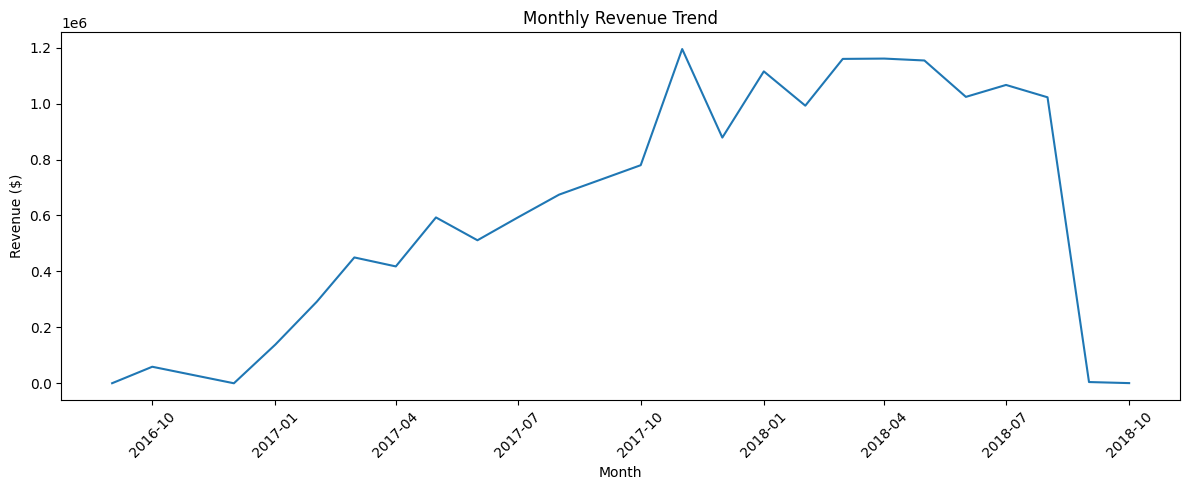

In [9]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby("purchase_year_month")["payment_value"]
      .sum()
      .reset_index()
      .sort_values("purchase_year_month")
)

monthly_revenue["purchase_year_month"] = pd.to_datetime(
    monthly_revenue["purchase_year_month"]
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_revenue,
    x="purchase_year_month",
    y="payment_value"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

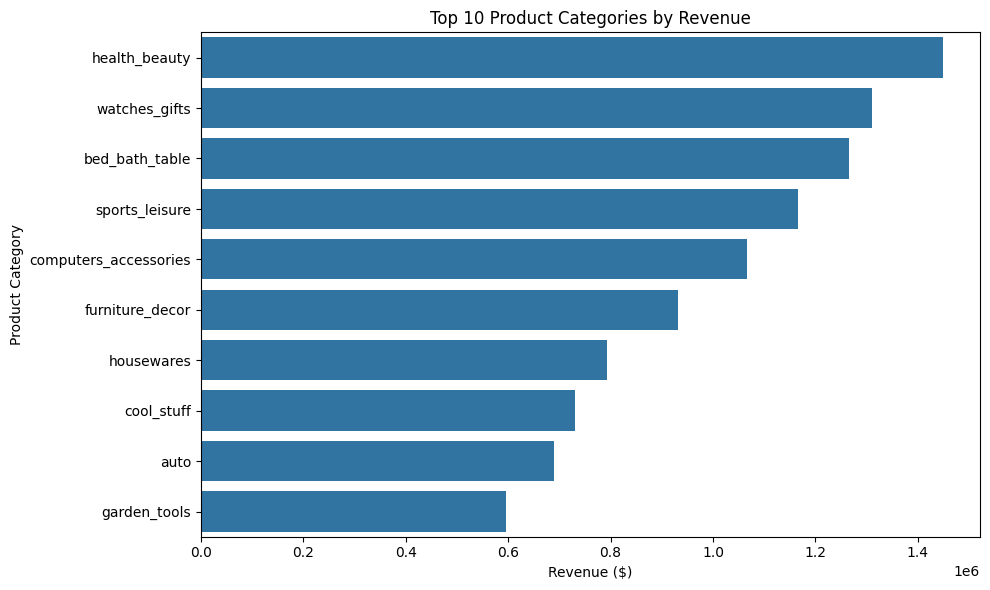

In [10]:
# Revenue by Product Category

category_revenue = (
    df.assign(product_category=df["product_categories"].str.split(","))
      .explode("product_category")
)

category_revenue["product_category"] = (
    category_revenue["product_category"].str.strip()
)

category_revenue = (
    category_revenue.groupby("product_category")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_revenue,
    x="payment_value",
    y="product_category"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

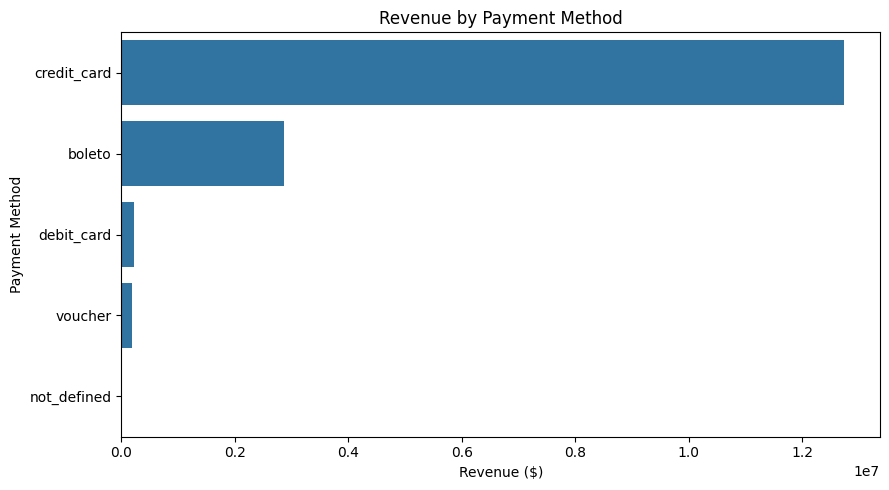

In [11]:
# Revenue by Payment Method

payment_revenue = (
    df.groupby("primary_payment_type")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=payment_revenue,
    x="payment_value",
    y="primary_payment_type"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Revenue ($)")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

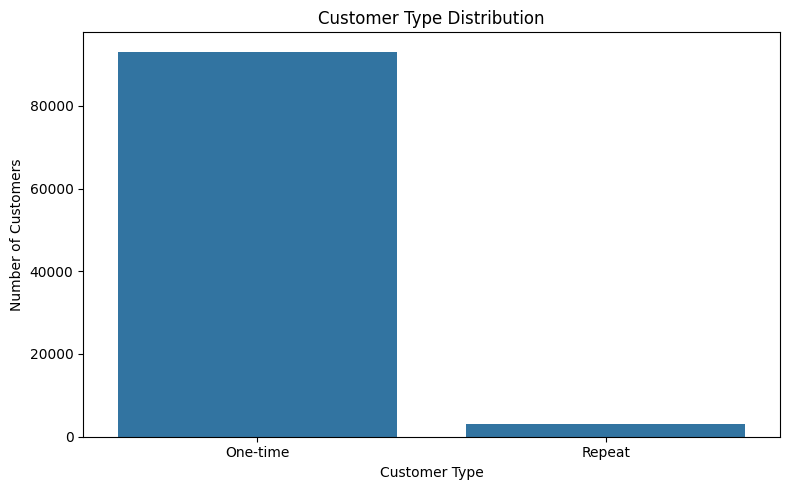

In [12]:
# Customer Segmentation using Repeat Customer Status

customer_segments = (
    df.groupby("is_repeat_customer")["customer_unique_id"]
      .nunique()
      .reset_index(name="customer_count")
)

customer_segments["customer_type"] = customer_segments["is_repeat_customer"].map({
    0: "One-time",
    1: "Repeat"
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=customer_segments,
    x="customer_type",
    y="customer_count"
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

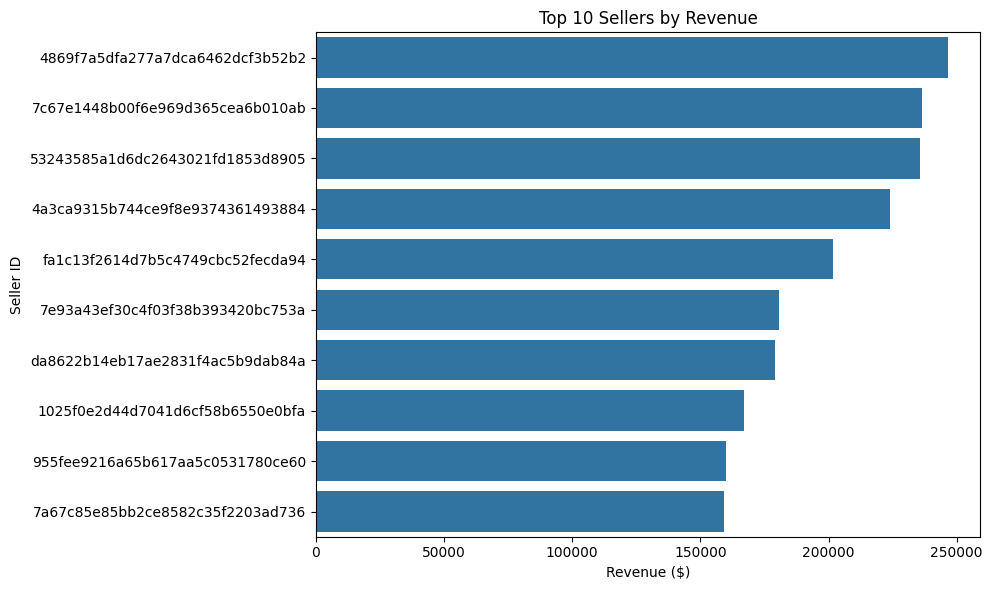

In [13]:
# Top 10 Sellers by Revenue

seller_revenue = (
    df.groupby("seller_ids")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=seller_revenue,
    x="payment_value",
    y="seller_ids"
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

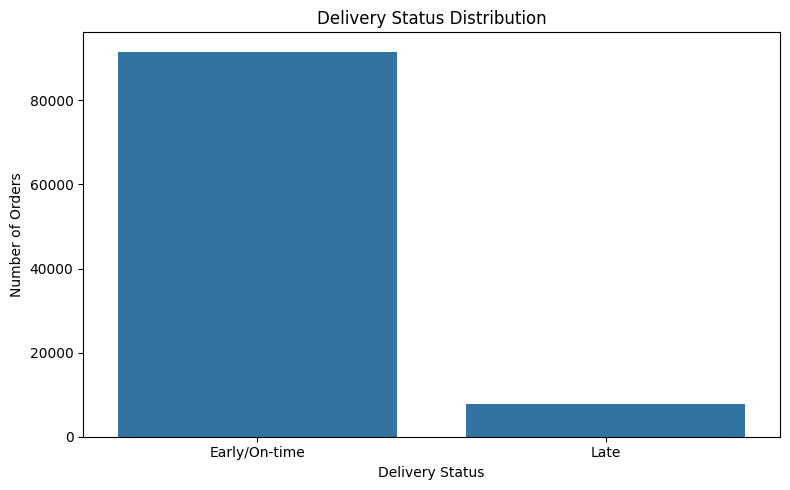

In [14]:
# Delivery Performance Analysis

delivery_status = (
    df["is_late"]
    .map({0: "Early/On-time", 1: "Late"})
    .value_counts()
    .reset_index()
)

delivery_status.columns = ["delivery_status", "order_count"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=delivery_status,
    x="delivery_status",
    y="order_count"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

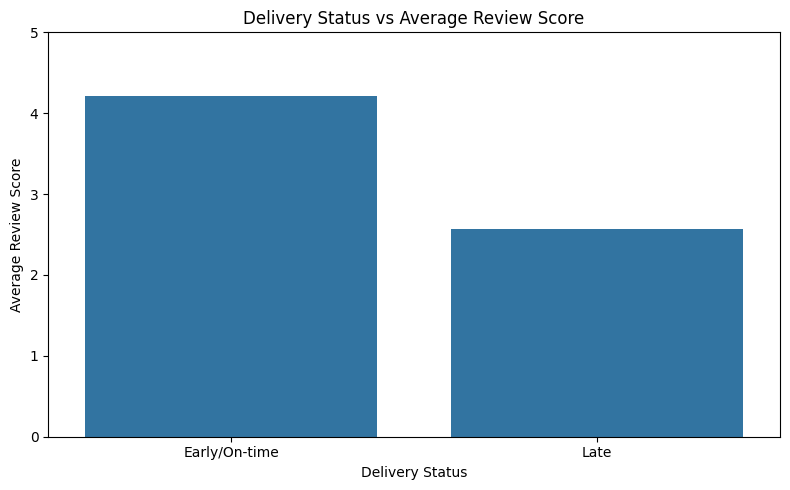

In [15]:
# Delivery Performance vs Customer Satisfaction

review_delivery = (
    df.groupby("is_late")["review_score_avg"]
      .mean()
      .reset_index()
)

review_delivery["delivery_status"] = review_delivery["is_late"].map({
    0: "Early/On-time",
    1: "Late"
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=review_delivery,
    x="delivery_status",
    y="review_score_avg"
)

plt.title("Delivery Status vs Average Review Score")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

,Metric,Value
0,Low Rating Rate (< 3),14.564415
1,Average Review Score,4.086793


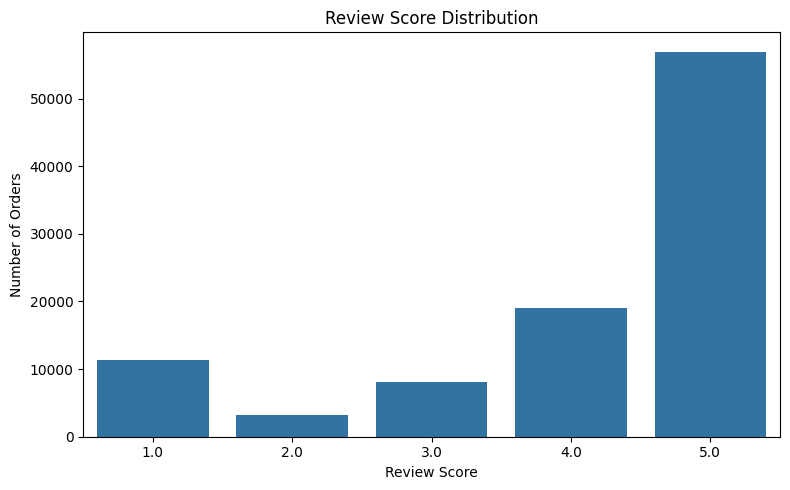

In [17]:
# Low Rating Analysis

low_rating_rate = (
    df["review_score_avg"].lt(3).mean() * 100
)

rating_summary = pd.DataFrame({
    "Metric": ["Low Rating Rate (< 3)", "Average Review Score"],
    "Value": [low_rating_rate, df["review_score_avg"].mean()]
})

display(rating_summary)

plt.figure(figsize=(8, 5))

rating_counts = (
    df["review_score_avg"]
    .round()
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

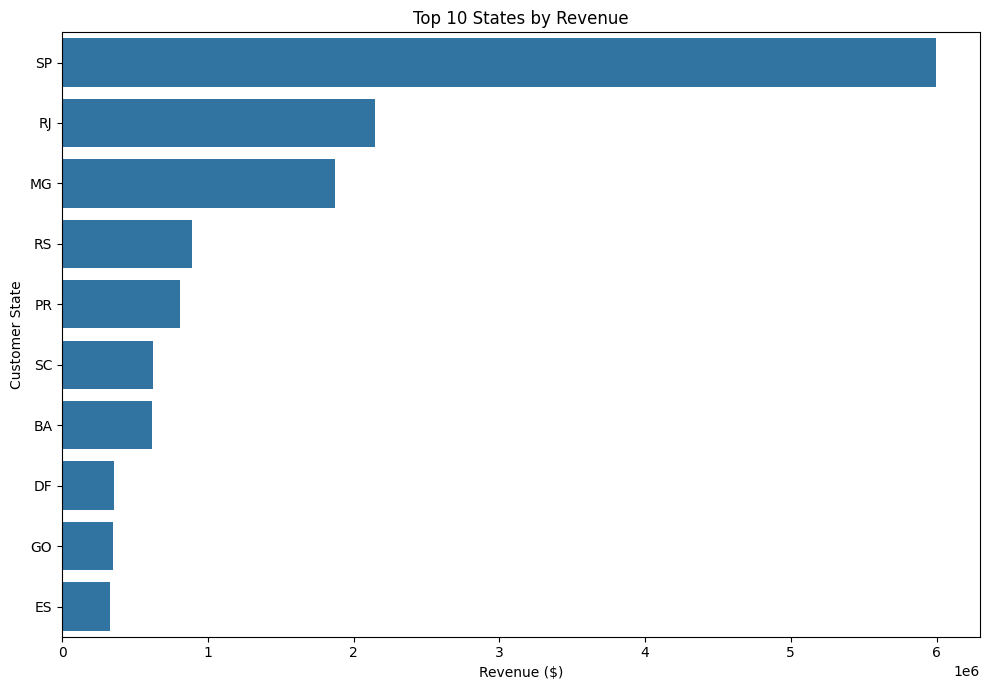

In [18]:
# Revenue by Customer State

state_revenue = (
    df.groupby("customer_state")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=state_revenue.head(10),
    x="payment_value",
    y="customer_state"
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

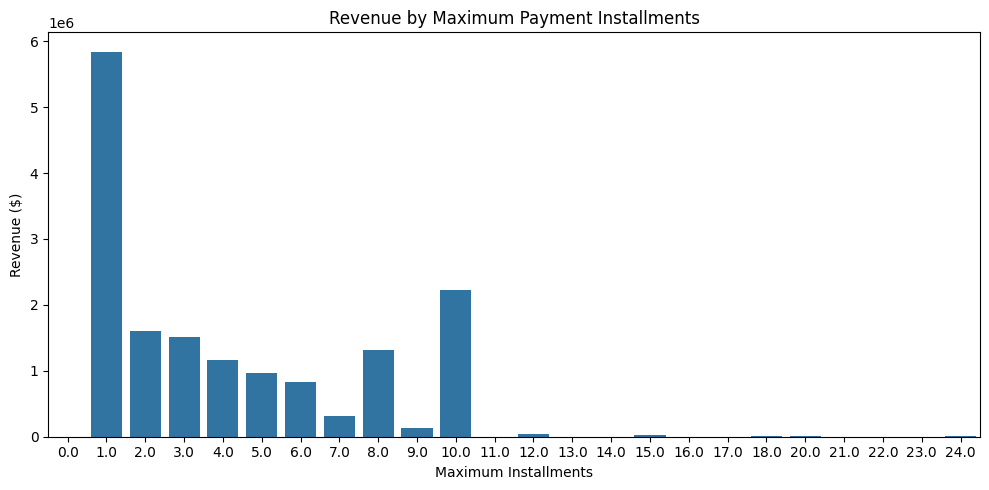

In [19]:
# Payment Installment Analysis

installment_analysis = (
    df.groupby("payment_installments_max")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=installment_analysis,
    x="payment_installments_max",
    y="payment_value"
)

plt.title("Revenue by Maximum Payment Installments")
plt.xlabel("Maximum Installments")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

,segment,Customers,Average_Spend
0,Champions,15167,298.347862
1,Low Value,15097,63.927555
2,Loyal,32600,198.230355
3,Needs Attention,33232,122.063259


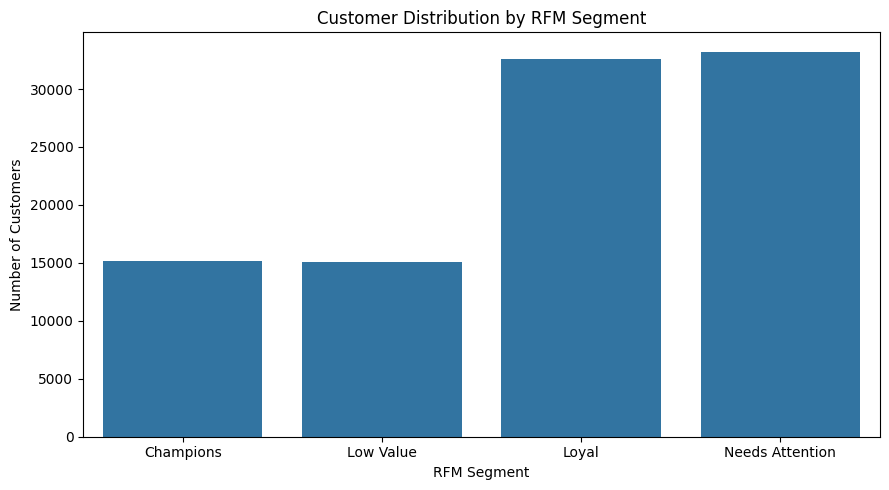

In [20]:
# RFM Customer Segmentation

import numpy as np

# Create customer-level RFM metrics
rfm = (
    df.groupby("customer_unique_id")
      .agg(
          Recency=("purchase_year_month", "max"),
          Frequency=("order_id", "nunique"),
          Monetary=("payment_value", "sum")
      )
      .reset_index()
)

# Convert purchase period into a numeric recency measure
max_period = df["purchase_year_month"].max()

rfm["Recency"] = (
    pd.to_datetime(max_period + "-01") -
    pd.to_datetime(rfm["Recency"] + "-01")
).dt.days

# Create RFM scores
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

# Define customer segments
def assign_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal"
    elif score >= 6:
        return "Needs Attention"
    else:
        return "Low Value"

rfm["segment"] = rfm["RFM_Score"].apply(assign_segment)

# Display segment distribution
segment_summary = (
    rfm.groupby("segment")
       .agg(
           Customers=("customer_unique_id", "count"),
           Average_Spend=("Monetary", "mean")
       )
       .reset_index()
)

display(segment_summary)

# Plot customer distribution
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary,
    x="segment",
    y="Customers"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

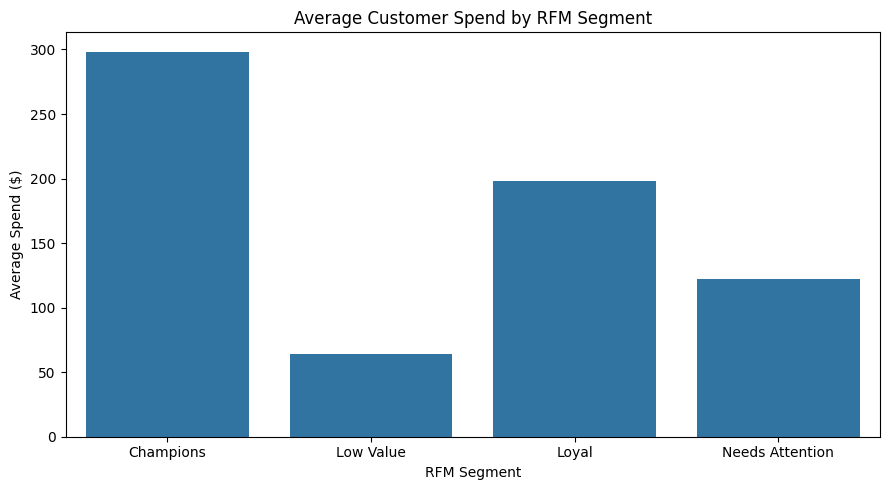

In [21]:
# Average Customer Spend by RFM Segment

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_summary,
    x="segment",
    y="Average_Spend"
)

plt.title("Average Customer Spend by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Spend ($)")
plt.tight_layout()
plt.show()

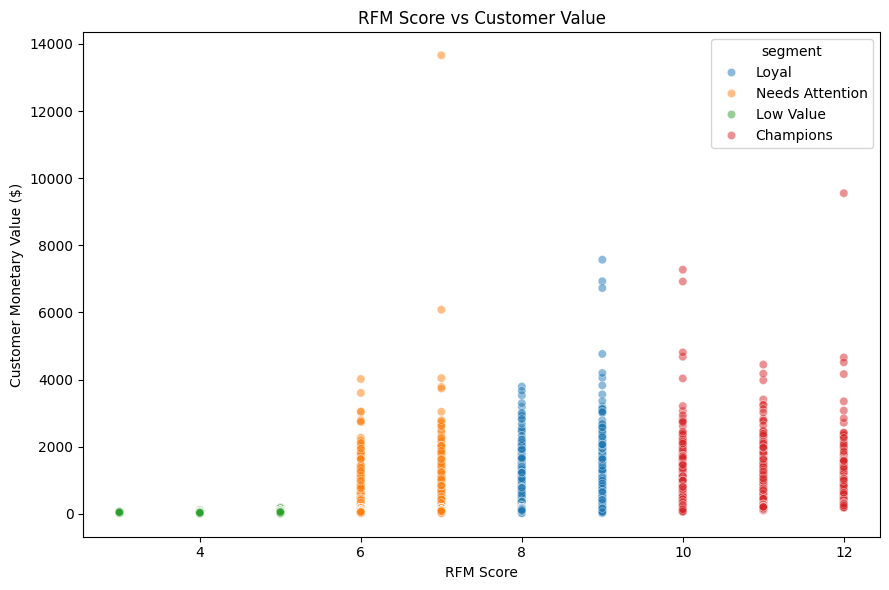

In [22]:
# RFM Score vs Customer Value

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="RFM_Score",
    y="Monetary",
    hue="segment",
    alpha=0.5
)

plt.title("RFM Score vs Customer Value")
plt.xlabel("RFM Score")
plt.ylabel("Customer Monetary Value ($)")
plt.tight_layout()
plt.show()

In [23]:
# Save RFM Customer Segmentation Results

rfm.to_csv(
    "../data/processed/rfm_customer_segments.csv",
    index=False
)

print("RFM segmentation saved successfully.")
print("Rows:", len(rfm))

RFM segmentation saved successfully.
Rows: 96096


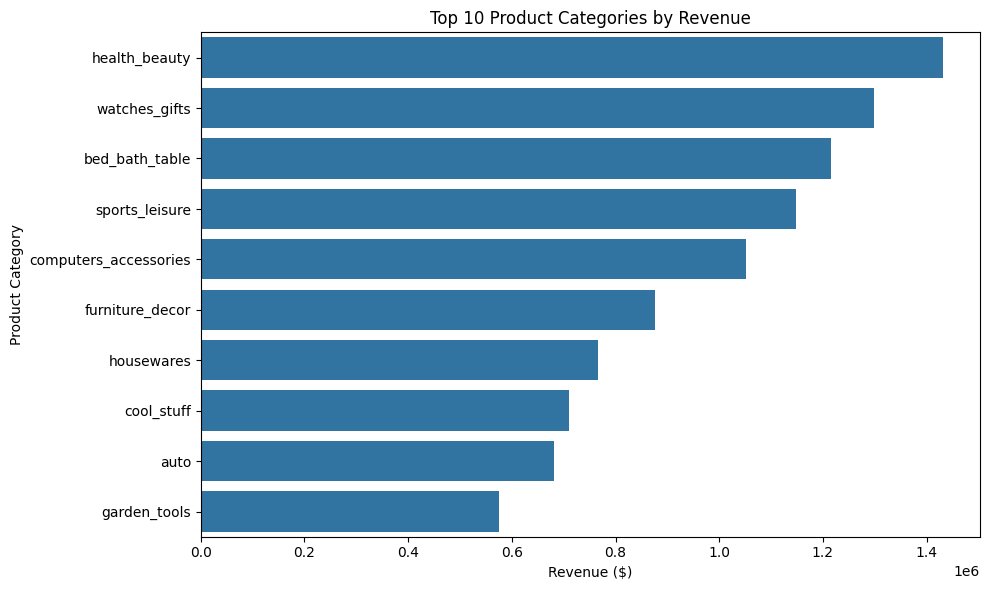

In [24]:
# Top 10 Products by Revenue

product_revenue = (
    df.groupby("product_categories")["payment_value"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_revenue,
    x="payment_value",
    y="product_categories"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

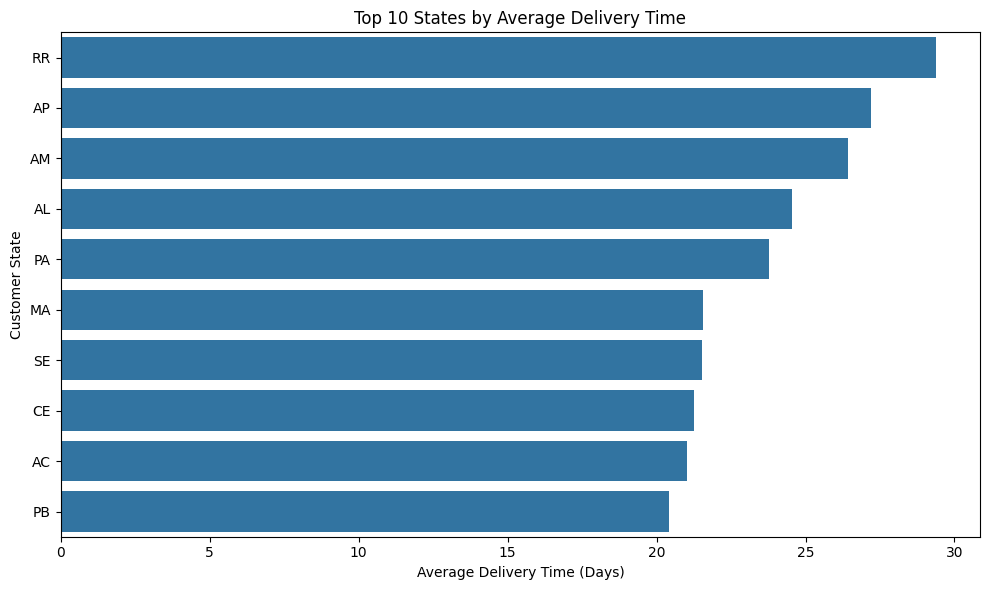

In [25]:
# Average Delivery Time by Customer State

state_delivery = (
    df.dropna(subset=["delivery_days"])
      .groupby("customer_state")["delivery_days"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_delivery,
    x="delivery_days",
    y="customer_state"
)

plt.title("Top 10 States by Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

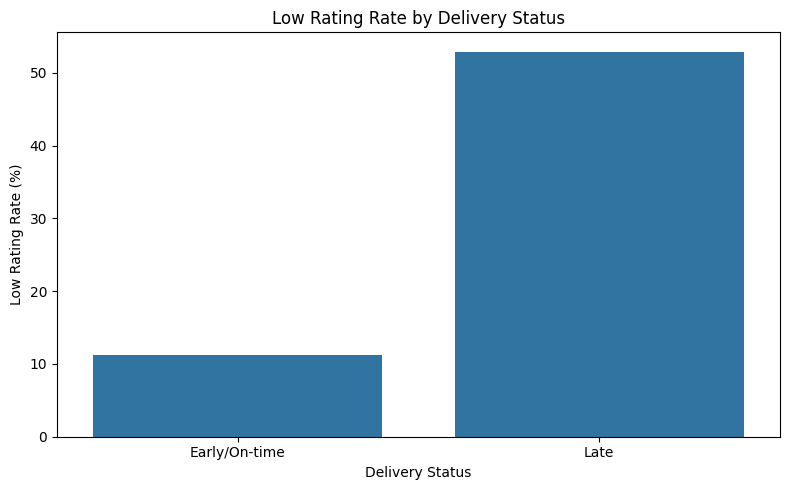

In [26]:
# Low Rating Rate by Delivery Status

low_rating_delivery = (
    df.assign(low_rating=df["review_score_avg"] < 3)
      .groupby("is_late")["low_rating"]
      .mean()
      .mul(100)
      .reset_index()
)

low_rating_delivery["delivery_status"] = low_rating_delivery["is_late"].map({
    0: "Early/On-time",
    1: "Late"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=low_rating_delivery,
    x="delivery_status",
    y="low_rating"
)

plt.title("Low Rating Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Low Rating Rate (%)")
plt.tight_layout()
plt.show()

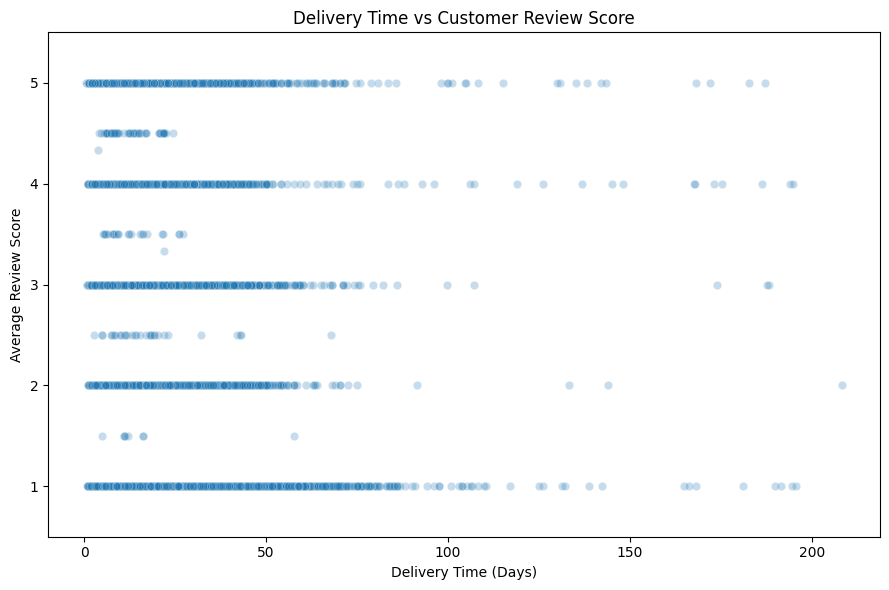

In [27]:
# Delivery Time vs Review Score

delivery_review = (
    df.dropna(subset=["delivery_days", "review_score_avg"])
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=delivery_review,
    x="delivery_days",
    y="review_score_avg",
    alpha=0.25
)

plt.title("Delivery Time vs Customer Review Score")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Average Review Score")
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

Top 5 Seller Revenue Share: 7.23%
Top 10 Seller Revenue Share: 12.55%


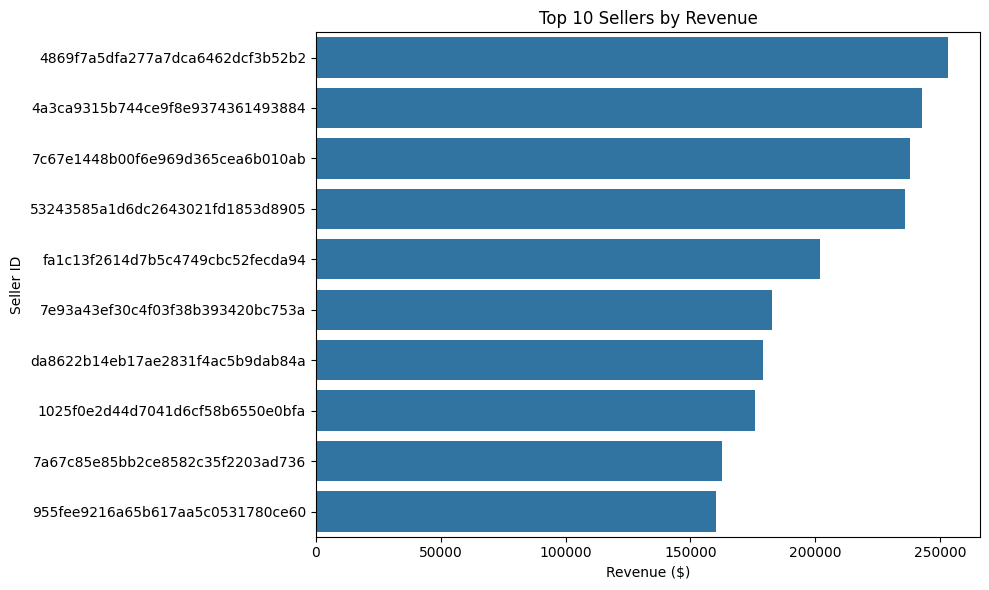

In [28]:
# Seller Revenue Concentration

seller_revenue = (
    df.assign(seller_id=df["seller_ids"].str.split(","))
      .explode("seller_id")
      .groupby("seller_id")["order_value"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

total_seller_revenue = seller_revenue["order_value"].sum()

top_10_seller_share = (
    seller_revenue.head(10)["order_value"].sum()
    / total_seller_revenue
    * 100
)

top_5_seller_share = (
    seller_revenue.head(5)["order_value"].sum()
    / total_seller_revenue
    * 100
)

print(f"Top 5 Seller Revenue Share: {top_5_seller_share:.2f}%")
print(f"Top 10 Seller Revenue Share: {top_10_seller_share:.2f}%")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=seller_revenue.head(10),
    x="order_value",
    y="seller_id"
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

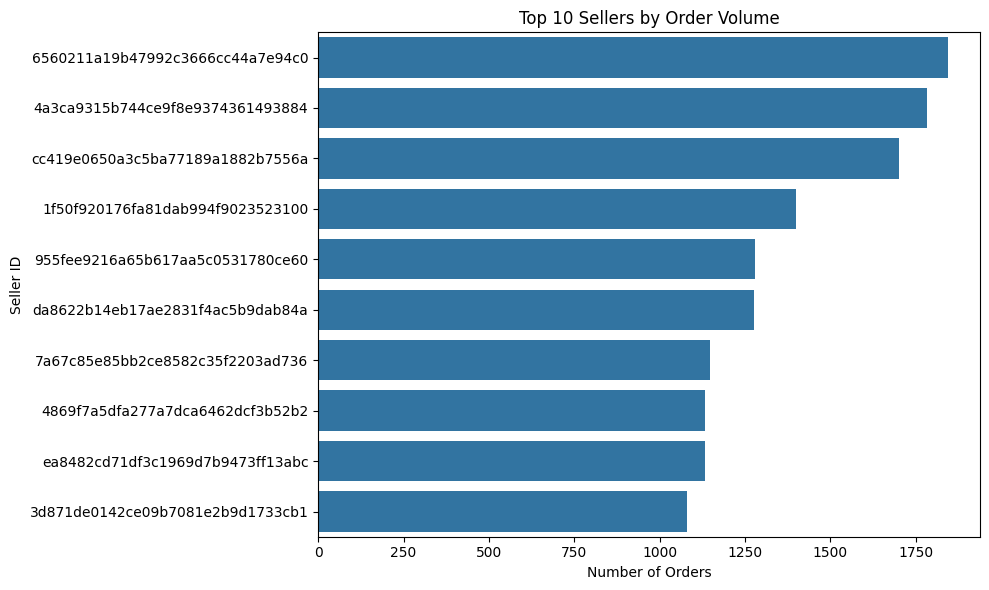

In [30]:
# Top 10 Sellers by Order Volume

seller_orders = (
    df.assign(seller_id=df["seller_ids"].str.split(","))
      .explode("seller_id")
      .groupby("seller_id")["order_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="orders")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=seller_orders,
    x="orders",
    y="seller_id"
)

plt.title("Top 10 Sellers by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

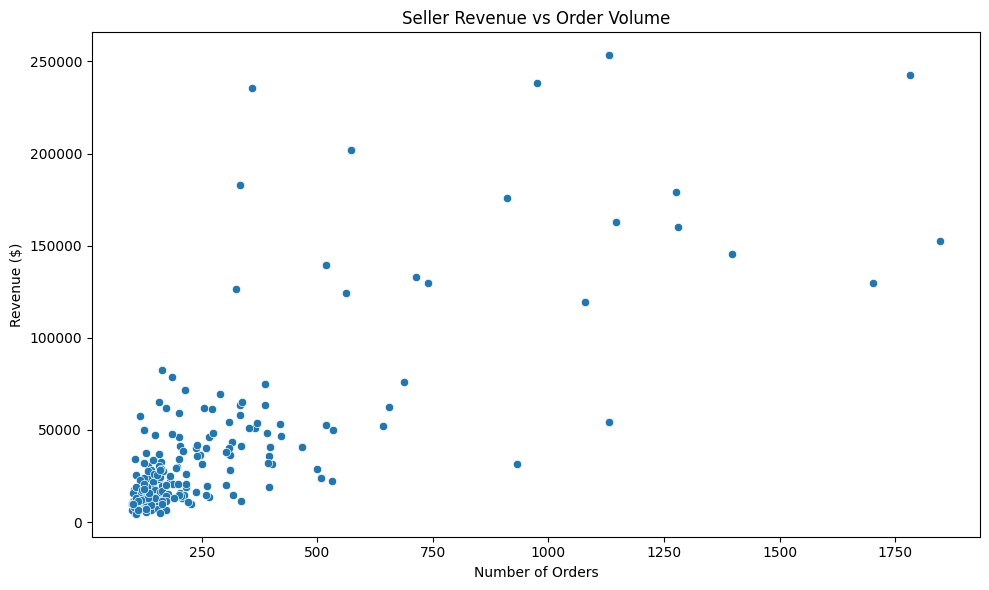

In [31]:
# Seller Revenue vs Order Volume

seller_analysis = (
    df.assign(seller_id=df["seller_ids"].str.split(","))
      .explode("seller_id")
      .groupby("seller_id")
      .agg(
          revenue=("order_value", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
)

# Keep sellers with meaningful activity
seller_analysis = seller_analysis[seller_analysis["orders"] >= 100]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=seller_analysis,
    x="orders",
    y="revenue"
)

plt.title("Seller Revenue vs Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

In [32]:
# Seller Revenue vs Order Volume Correlation

correlation = seller_analysis["orders"].corr(
    seller_analysis["revenue"]
)

print(f"Correlation between Order Volume and Revenue: {correlation:.3f}")

Correlation between Order Volume and Revenue: 0.758


In [33]:
# Seller Revenue per Order

seller_analysis["revenue_per_order"] = (
    seller_analysis["revenue"] / seller_analysis["orders"]
)

top_value_sellers = (
    seller_analysis
    .sort_values("revenue_per_order", ascending=False)
    .head(10)
)

display(top_value_sellers)

,seller_id,revenue,orders,revenue_per_order
1541,53243585a1d6dc2643021fd1853d8905,235856.68,358,658.817542
2086,7e93a43ef30c4f03f38b393420bc753a,182857.11,334,547.476377
3391,edb1ef5e36e0c8cd84eb3c9b003e486d,82344.18,164,502.098659
3490,f5a590cf36251cf1162ea35bef76fe84,57440.94,117,490.948205
3012,ccc4bbb5f32a6ab2b7066a4130f114e3,78544.82,185,424.566595
970,25c5c91f63607446a97b143d2d535d31,65203.98,158,412.683418
807,17a053fcb14bd219540cbde0df490be0,49883.63,125,399.069040
1680,5dceca129747e92ff8ef7a997dc4f8ca,126258.37,324,389.686327
1517,522620dcb18a6b31cd7bdf73665113a9,61905.53,174,355.778908
3544,fa1c13f2614d7b5c4749cbc52fecda94,201788.35,573,352.161169


In [34]:
# High-Value Sellers with Minimum Order Volume

high_value_sellers = (
    seller_analysis[
        seller_analysis["orders"] >= 50
    ]
    .sort_values("revenue_per_order", ascending=False)
    .head(10)
)

display(
    high_value_sellers[
        ["seller_id", "orders", "revenue", "revenue_per_order"]
    ]
)

,seller_id,orders,revenue,revenue_per_order
1541,53243585a1d6dc2643021fd1853d8905,358,235856.68,658.817542
2086,7e93a43ef30c4f03f38b393420bc753a,334,182857.11,547.476377
3391,edb1ef5e36e0c8cd84eb3c9b003e486d,164,82344.18,502.098659
3490,f5a590cf36251cf1162ea35bef76fe84,117,57440.94,490.948205
3012,ccc4bbb5f32a6ab2b7066a4130f114e3,185,78544.82,424.566595
970,25c5c91f63607446a97b143d2d535d31,158,65203.98,412.683418
807,17a053fcb14bd219540cbde0df490be0,125,49883.63,399.069040
1680,5dceca129747e92ff8ef7a997dc4f8ca,324,126258.37,389.686327
1517,522620dcb18a6b31cd7bdf73665113a9,174,61905.53,355.778908
3544,fa1c13f2614d7b5c4749cbc52fecda94,573,201788.35,352.161169


In [35]:
# Seller Revenue Concentration

total_seller_revenue = seller_analysis["revenue"].sum()

concentration = {}

for n in [1, 5, 10, 20, 50]:
    top_n_revenue = (
        seller_analysis
        .nlargest(n, "revenue")["revenue"]
        .sum()
    )
    
    concentration[f"Top {n}"] = (
        top_n_revenue / total_seller_revenue * 100
    )

concentration_df = pd.DataFrame(
    list(concentration.items()),
    columns=["Seller Group", "Revenue Share (%)"]
)

display(concentration_df)

,Seller Group,Revenue Share (%)
0,Top 1,3.072917
1,Top 5,14.211895
2,Top 10,24.655265
3,Top 20,40.207407
4,Top 50,61.625192


In [37]:
print("Total seller revenue:", seller_analysis["revenue"].sum())
print("Top 10 seller revenue:",
      seller_analysis.nlargest(10, "revenue")["revenue"].sum())

print(
    "Top 10 share:",
    seller_analysis.nlargest(10, "revenue")["revenue"].sum()
    / seller_analysis["revenue"].sum() * 100
)

Total seller revenue: 8245234.63
Top 10 seller revenue: 2032884.46
Top 10 share: 24.65526514677242


In [38]:
# RFM Segment Revenue Contribution

rfm_summary = (
    rfm.groupby("segment")
    .agg(
        Customers=("customer_unique_id", "nunique"),
        Revenue=("monetary", "sum"),
        Average_Spend=("monetary", "mean")
    )
    .reset_index()
)

rfm_summary["Revenue_Share_%"] = (
    rfm_summary["Revenue"] /
    rfm_summary["Revenue"].sum() * 100
)

rfm_summary = rfm_summary.sort_values(
    "Revenue",
    ascending=False
)

display(rfm_summary)

KeyError: "Column(s) ['monetary'] do not exist"

In [39]:
print(rfm.columns.tolist())

['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'segment']


In [40]:
# RFM Segment Revenue Contribution

rfm_summary = (
    rfm.groupby("segment")
    .agg(
        Customers=("customer_unique_id", "nunique"),
        Revenue=("Monetary", "sum"),
        Average_Spend=("Monetary", "mean")
    )
    .reset_index()
)

rfm_summary["Revenue_Share_%"] = (
    rfm_summary["Revenue"] /
    rfm_summary["Revenue"].sum() * 100
)

rfm_summary = rfm_summary.sort_values(
    "Revenue",
    ascending=False
)

display(rfm_summary)

,segment,Customers,Revenue,Average_Spend,Revenue_Share_%
2,Loyal,32600,6462309.57,198.230355,40.367051
0,Champions,15167,4525042.02,298.347862,28.265839
3,Needs Attention,33232,4056406.23,122.063259,25.338489
1,Low Value,15097,965114.30,63.927555,6.028621


In [44]:
# Repeat vs One-Time Customer Analysis

customer_analysis = (
    df.groupby("customer_unique_id")
    .agg(
        Orders=("order_id", "nunique"),
        Revenue=("order_value", "sum")
    )
    .reset_index()
)

customer_analysis["Customer_Type"] = np.where(
    customer_analysis["Orders"] > 1,
    "Repeat",
    "One-time"
)

retention_summary = (
    customer_analysis
    .groupby("Customer_Type")
    .agg(
        Customers=("customer_unique_id", "count"),
        Total_Revenue=("Revenue", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Average_Orders=("Orders", "mean")
    )
    .reset_index()
)

retention_summary["Customer_Share_%"] = (
    retention_summary["Customers"] /
    retention_summary["Customers"].sum() * 100
)

retention_summary["Revenue_Share_%"] = (
    retention_summary["Total_Revenue"] /
    retention_summary["Total_Revenue"].sum() * 100
)

display(retention_summary)

,Customer_Type,Customers,Total_Revenue,Average_Revenue,Average_Orders,Customer_Share_%,Revenue_Share_%
0,One-time,93099,14921510.75,160.275736,1.000000,96.881244,94.18033
1,Repeat,2997,922042.49,307.655152,2.116116,3.118756,5.81967


In [42]:
print("df" in globals())

True


In [43]:
print([x for x in globals().keys() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'plt', 'sns', 'df', 'missing', 'total_revenue', 'total_orders', 'total_customers', 'delivered_orders', 'average_order_value', 'late_delivery_rate', 'average_delivery_days', 'average_review_score', 'repeat_customer_rate', 'kpis', 'monthly_revenue', 'category_revenue', 'payment_revenue', 'customer_segments', 'seller_revenue', 'delivery_status', 'review_delivery', 'low_rating_rate', 'rating_summary', 'rating_counts', 'state_revenue', 'installment_analysis', 'rfm', 'max_period', 'assign_segment', 'segment_summary', 'product_revenue', 'state_delivery', 'low_rating_delivery', 'delivery_review', 'total_seller_revenue', 'top_10_seller_share', 'top_5_seller_share', 'seller_orders', 'seller_analysis', 'correlation', 'top_value_sellers', 'high_value_sellers', 'concentration', 'n', 'top_n_revenue', 'concentration_df', 'rfm_summary', 'customer_analysis', 'retention_summary']


In [45]:
# Repeat Customer Revenue Comparison

repeat_comparison = (
    customer_analysis
    .groupby("Customer_Type")
    .agg(
        Customers=("customer_unique_id", "count"),
        Total_Revenue=("Revenue", "sum"),
        Average_Revenue_Per_Customer=("Revenue", "mean"),
        Average_Orders_Per_Customer=("Orders", "mean")
    )
    .reset_index()
)

repeat_comparison["Revenue_Per_Customer_Index"] = (
    repeat_comparison["Average_Revenue_Per_Customer"]
    / repeat_comparison["Average_Revenue_Per_Customer"].min()
)

display(repeat_comparison)

,Customer_Type,Customers,Total_Revenue,Average_Revenue_Per_Customer,Average_Orders_Per_Customer,Revenue_Per_Customer_Index
0,One-time,93099,14921510.75,160.275736,1.000000,1.000000
1,Repeat,2997,922042.49,307.655152,2.116116,1.919537


,Orders_Per_Customer,Customers
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


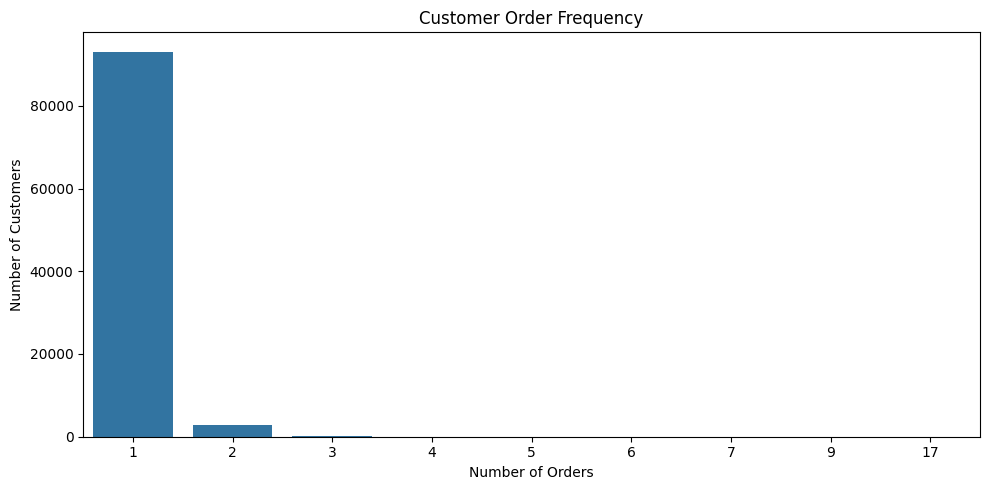

In [46]:
# Customer Order Frequency Distribution

order_frequency = (
    customer_analysis["Orders"]
    .value_counts()
    .sort_index()
    .reset_index()
)

order_frequency.columns = ["Orders_Per_Customer", "Customers"]

display(order_frequency.head(10))

plt.figure(figsize=(10, 5))

sns.barplot(
    data=order_frequency.head(10),
    x="Orders_Per_Customer",
    y="Customers"
)

plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()